In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Đường dẫn chính xác 
data_path = r'D:\Kì 1 N4\Phát triển các hệ thống thông minh\Assignment_02\diabetes\data\diabetes_dataset.csv'

if not os.path.exists(data_path):
    print("Lỗi: Vẫn không tìm thấy file!")
else:
    df = pd.read_csv(data_path)
    print(f"-> Nạp thành công dữ liệu từ: {data_path}")
    print(f"-> Kích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")

-> Nạp thành công dữ liệu từ: D:\Kì 1 N4\Phát triển các hệ thống thông minh\Assignment_02\diabetes\data\diabetes_dataset.csv
-> Kích thước tập dữ liệu: 100000 dòng, 16 cột


In [2]:
# Hiển thị 5 dòng đầu tiên
print("=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===")
display(df.head())

# Thông tin tổng quát về kiểu dữ liệu và bộ nhớ
print("\n=== THÔNG TIN KIỂU DỮ LIỆU (INFO) ===")
df.info()

# Thống kê mô tả các thuộc tính số
print("\n=== THỐNG KÊ MÔ TẢ (DESCRIBE) ===")
display(df.describe())

=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0



=== THÔNG TIN KIỂU DỮ LIỆU (INFO) ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [3]:
# Kiểm tra giá trị NaN thực tế trong DataFrame
print("Số lượng giá trị NaN theo chuẩn Pandas:")
print(df.isna().sum())

Số lượng giá trị NaN theo chuẩn Pandas:
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64


In [4]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp hoàn toàn: {num_duplicates}")

Số lượng bản ghi trùng lặp hoàn toàn: 14


In [5]:
print("Danh sách các cột hiện có trong file:")
print(list(df.columns))

# In 3 dòng đầu để xem dữ liệu mẫu
df.head(3)


Danh sách các cột hiện có trong file:
['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0


In [6]:
# Danh sách các cột số sinh học cần kiểm tra giá trị 0 hoặc missing bất thường
invalid_cols = ["blood_glucose_level", "bmi", "hbA1c_level", "age"]

invalid_counts = {}
for col in invalid_cols:
    count_zeros = (df[col] == 0).sum()
    pct_zeros = (count_zeros / len(df)) * 100
    invalid_counts[col] = {
        "Số lượng 0": count_zeros,
        "Tỷ lệ (%)": round(pct_zeros, 2),
    }

# Hiển thị dạng bảng trực quan
missing_df = pd.DataFrame(invalid_counts).T
print(missing_df)

                     Số lượng 0  Tỷ lệ (%)
blood_glucose_level         0.0        0.0
bmi                         0.0        0.0
hbA1c_level                 0.0        0.0
age                         0.0        0.0


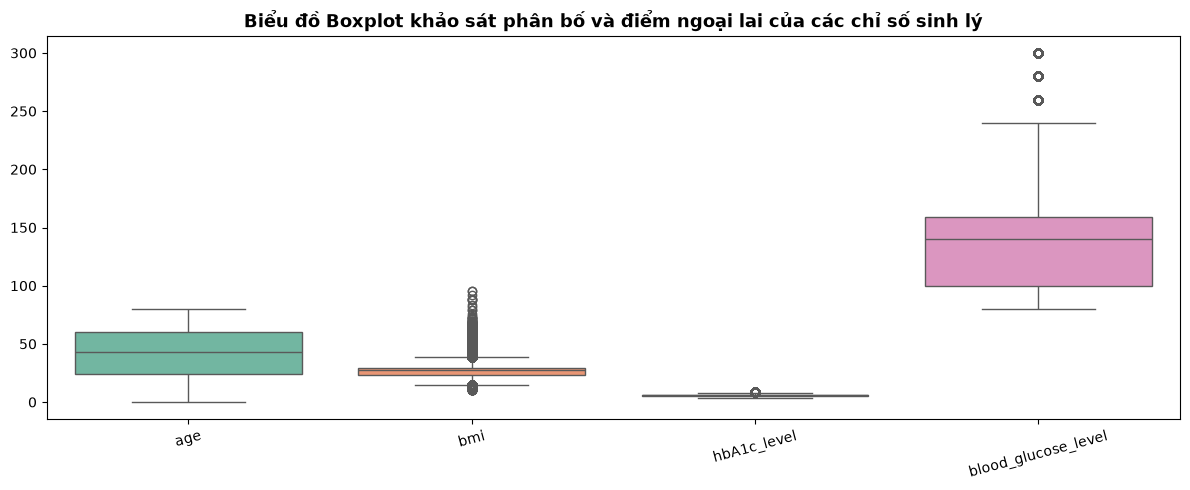

In [7]:
plt.figure(figsize=(12, 5))
features_to_plot = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
sns.boxplot(data=df[features_to_plot], palette='Set2')
plt.title(
    'Biểu đồ Boxplot khảo sát phân bố và điểm ngoại lai của các chỉ số sinh lý',
    fontsize=13,
    fontweight='bold',
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

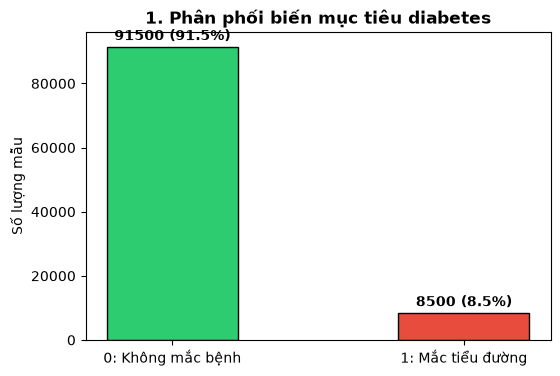

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ECC71', '#E74C3C']
counts = df['diabetes'].value_counts()
bars = ax.bar(
    ['0: Không mắc bệnh', '1: Mắc tiểu đường'],
    counts.values,
    color=colors,
    width=0.45,
    edgecolor='black',
)
for bar in bars:
  yval = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + (len(df) * 0.01),
      f'{yval} ({yval/len(df)*100:.1f}%)',
      ha='center',
      va='bottom',
      fontweight='bold',
  )
plt.title('1. Phân phối biến mục tiêu diabetes', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng mẫu')
plt.show()

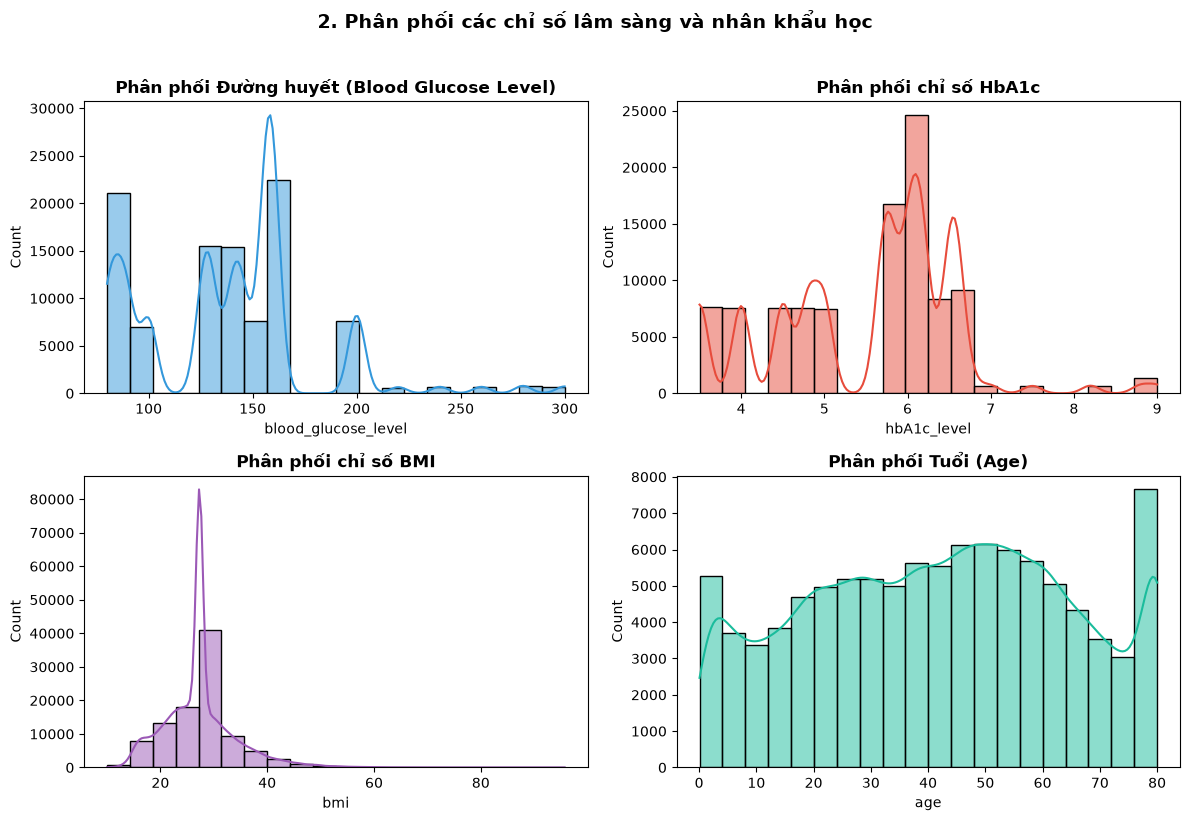

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(
    df['blood_glucose_level'],
    kde=True,
    ax=axes[0, 0],
    color='#3498DB',
    bins=20,
)
axes[0, 0].set_title(
    'Phân phối Đường huyết (Blood Glucose Level)', fontweight='bold'
)

sns.histplot(df['hbA1c_level'], kde=True, ax=axes[0, 1], color='#E74C3C', bins=20)
axes[0, 1].set_title('Phân phối chỉ số HbA1c', fontweight='bold')

sns.histplot(df['bmi'], kde=True, ax=axes[1, 0], color='#9B59B6', bins=20)
axes[1, 0].set_title('Phân phối chỉ số BMI', fontweight='bold')

sns.histplot(df['age'], kde=True, ax=axes[1, 1], color='#1ABC9C', bins=20)
axes[1, 1].set_title('Phân phối Tuổi (Age)', fontweight='bold')

plt.suptitle(
    '2. Phân phối các chỉ số lâm sàng và nhân khẩu học',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

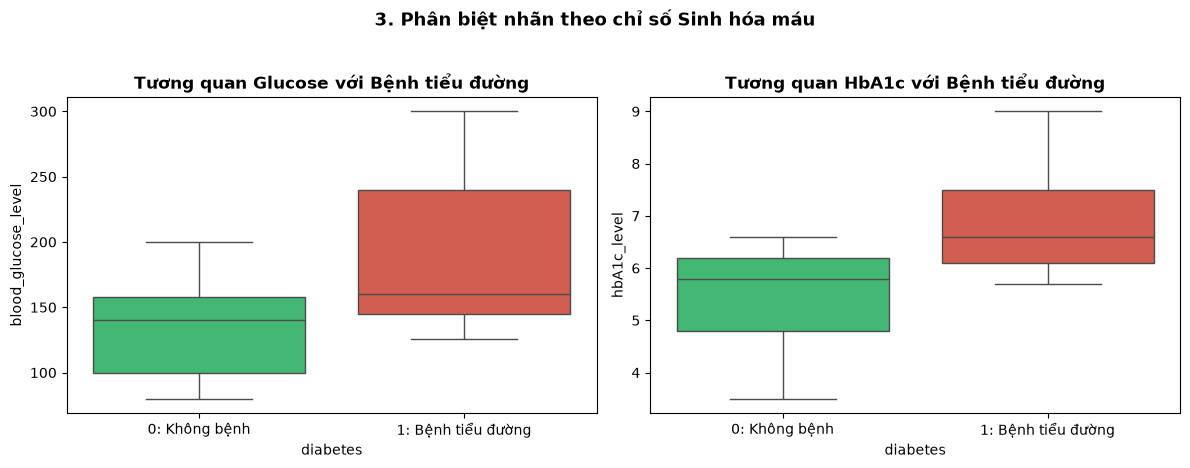

In [10]:
# Ép kiểu cột diabetes về số nguyên để đồng bộ dữ liệu
df['diabetes'] = df['diabetes'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
palette = {0: '#2ECC71', 1: '#E74C3C'}

# Đồ thị 1: Glucose vs diabetes
sns.boxplot(
    data=df,
    x='diabetes',
    y='blood_glucose_level',
    hue='diabetes',
    palette=palette,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Tương quan Glucose với Bệnh tiểu đường', fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0: Không bệnh', '1: Bệnh tiểu đường'])

# Đồ thị 2: HbA1c vs diabetes
sns.boxplot(
    data=df,
    x='diabetes',
    y='hbA1c_level',
    hue='diabetes',
    palette=palette,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Tương quan HbA1c với Bệnh tiểu đường', fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['0: Không bệnh', '1: Bệnh tiểu đường'])

plt.suptitle('3. Phân biệt nhãn theo chỉ số Sinh hóa máu', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

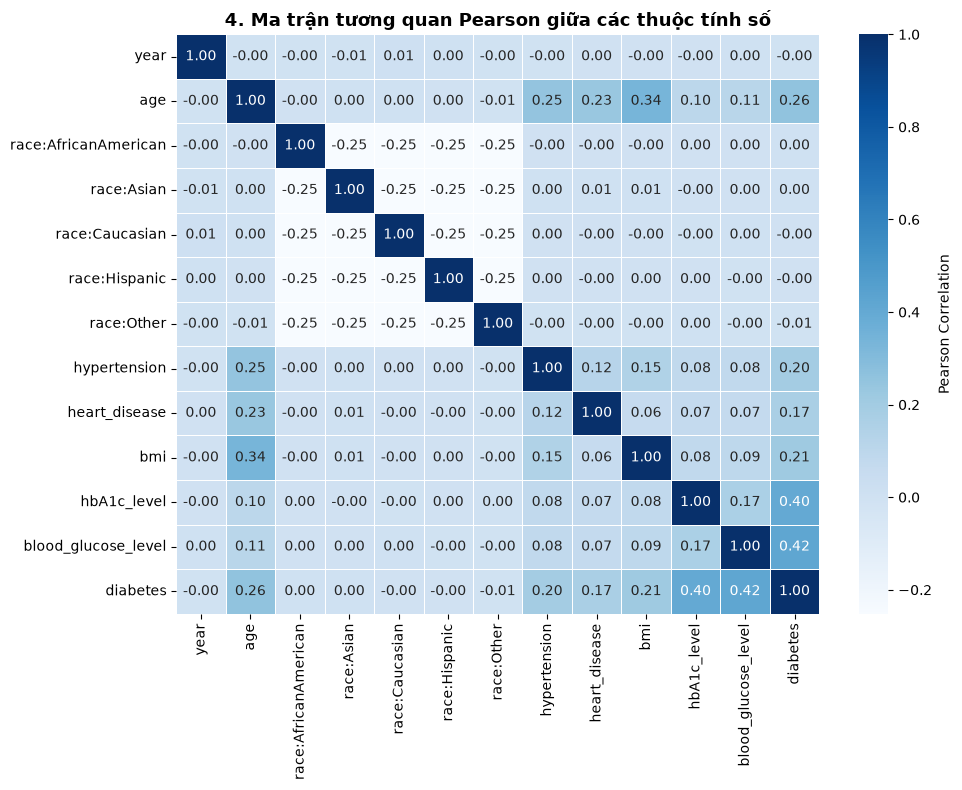

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
corr = numeric_df.corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'},
)
plt.title(
    '4. Ma trận tương quan Pearson giữa các thuộc tính số',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

In [12]:
drop_cols = [c for c in ['year', 'location', 'diabetes'] if c in df.columns]
X = df.drop(columns=drop_cols)
y = df['diabetes']

print(f'-> Danh sách đặc trưng đầu vào ({len(X.columns)} cột): {list(X.columns)}')
print(f'-> Kích thước ma trận đặc trưng X: {X.shape}')
print(f'-> Kích thước vector nhãn mục tiêu y: {y.shape}')

-> Danh sách đặc trưng đầu vào (13 cột): ['gender', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level']
-> Kích thước ma trận đặc trưng X: (100000, 13)
-> Kích thước vector nhãn mục tiêu y: (100000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(
    f'-> Tập huấn luyện (Train): {X_train.shape[0]} mẫu'
    f' ({X_train.shape[0]/len(X)*100:.1f}%)'
)
print(
    f'-> Tập kiểm thử (Test): {X_test.shape[0]} mẫu'
    f' ({X_test.shape[0]/len(X)*100:.1f}%)'
)

-> Tập huấn luyện (Train): 80000 mẫu (80.0%)
-> Tập kiểm thử (Test): 20000 mẫu (20.0%)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Lấy danh sách cột số
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Chỉ định rõ ràng 'object', 'category', 'string' để tương thích các phiên bản Pandas mới
cat_cols = X_train.select_dtypes(
    include=['object', 'category', 'string', 'str']
).columns.tolist()

num_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
)

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
])

# FIT DUY NHẤT TRÊN TẬP TRAIN (Chống Data Leakage)
X_train_processed = preprocessor.fit_transform(X_train)
# CHỈ TRANSFORM TRÊN TẬP TEST
X_test_processed = preprocessor.transform(X_test)

print(f'-> Kích thước ma trận Train sau xử lý: {X_train_processed.shape}')
print(f'-> Kích thước ma trận Test sau xử lý: {X_test_processed.shape}')

-> Kích thước ma trận Train sau xử lý: (80000, 20)
-> Kích thước ma trận Test sau xử lý: (20000, 20)


In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_processed, y_train)
y_pred_base = baseline.predict(X_test_processed)

print(f'Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.4f}')
print(
    f'Baseline F1-Score: {f1_score(y_test, y_pred_base, zero_division=0):.4f}'
)

Baseline Accuracy: 0.9150
Baseline F1-Score: 0.0000


In [16]:
import time
import numpy as np
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# 1. Lấy mẫu 10,000 dòng để mô hình học siêu tốc
np.random.seed(42)
sample_size = min(10000, len(X_train_processed))
indices = np.random.choice(len(X_train_processed), sample_size, replace=False)

X_train_fast = X_train_processed[indices]
y_train_fast = y_train.iloc[indices]

# 2. Khởi tạo Baseline Model
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_fast, y_train_fast)

# 3. Khai báo 5 mô hình với tham số tối ưu tốc độ
models = {
    'Baseline (Dummy)': baseline,
    'Logistic Regression': LogisticRegression(max_iter=300, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=50, max_depth=8, random_state=42, n_jobs=-1
    ),
    'Support Vector Machine': CalibratedClassifierCV(
        LinearSVC(dual=False, random_state=42)
    ),
}

# 4. Huấn luyện
print(f'=== BẮT ĐẦU HUẤN LUYỆN TRÊN {sample_size} MẪU ===')
for name, model in models.items():
  if name != 'Baseline (Dummy)':
    t0 = time.time()
    print(f'-> Đang chạy: {name}...', end=' ')
    model.fit(X_train_fast, y_train_fast)
    print(f'Xong! ({time.time() - t0:.2f}s)')

print('-> Đã hoàn thành toàn bộ trong vài giây!')

=== BẮT ĐẦU HUẤN LUYỆN TRÊN 10000 MẪU ===
-> Đang chạy: Logistic Regression... Xong! (0.08s)
-> Đang chạy: K-Nearest Neighbors... Xong! (0.00s)
-> Đang chạy: Decision Tree... Xong! (0.04s)
-> Đang chạy: Random Forest... Xong! (0.30s)
-> Đang chạy: Support Vector Machine... Xong! (0.17s)
-> Đã hoàn thành toàn bộ trong vài giây!


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    try:
        y_prob = model.predict_proba(X_test_processed)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = 0.5
        
    results.append({
        'Mô hình': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(auc, 4)
    })

df_results = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("=== BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH TRÊN TẬP TEST ===")
display(df_results)

=== BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH TRÊN TẬP TEST ===


,Mô hình,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Random Forest,0.9724,1.0000,0.6747,0.8058,0.9628
3,Decision Tree,0.9723,1.0000,0.6741,0.8053,0.9508
5,Support Vector Machine,0.9604,0.8684,0.6288,0.7294,0.9618
1,Logistic Regression,0.9596,0.8555,0.6306,0.7260,0.9619
2,K-Nearest Neighbors,0.9528,0.9031,0.4988,0.6427,0.8972
0,Baseline (Dummy),0.9150,0.0000,0.0000,0.0000,0.5000


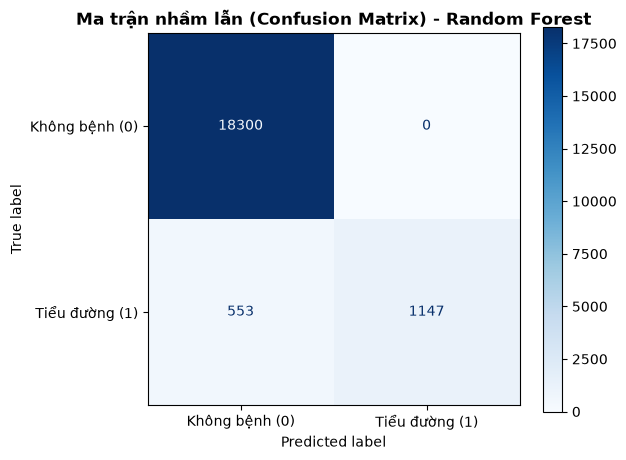

True Negative (Đoán đúng không bệnh): 18300
False Positive (Báo động giả): 0
False Negative (BỎ SÓT BỆNH NHÂN): 553
True Positive (Phát hiện đúng bệnh): 1147


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Chọn mô hình Random Forest
best_clf = models['Random Forest']
y_pred_best = best_clf.predict(X_test_processed)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Không bệnh (0)', 'Tiểu đường (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Random Forest', fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative (Đoán đúng không bệnh): {tn}")
print(f"False Positive (Báo động giả): {fp}")
print(f"False Negative (BỎ SÓT BỆNH NHÂN): {fn}")
print(f"True Positive (Phát hiện đúng bệnh): {tp}")

In [23]:
import os
import joblib

# Đường dẫn chính xác theo ảnh Explorer của bạn
save_dir = (
    r'D:\Kì 1 N4\Phát triển các hệ thống thông minh\Assignment_02\diabetes\model'
)
os.makedirs(save_dir, exist_ok=True)

# Đóng gói cả preprocessor và model thành 1 file diabetes.sav duy nhất
full_pipeline = {'preprocessor': preprocessor, 'model': best_clf}

file_path = os.path.join(save_dir, 'diabetes.sav')
joblib.dump(full_pipeline, file_path)

print(f'-> [OK] Đã cập nhật thành công file: {file_path}')

-> [OK] Đã cập nhật thành công file: D:\Kì 1 N4\Phát triển các hệ thống thông minh\Assignment_02\diabetes\model\diabetes.sav


In [24]:
import joblib
import pandas as pd

# 1. Nạp pipeline từ file diabetes.sav
saved_obj = joblib.load(file_path)
loaded_preprocessor = saved_obj['preprocessor']
loaded_model = saved_obj['model']

# 2. Giả lập dữ liệu bệnh nhân mới
sample_patient = {}
for col in X.columns:
  if col == 'gender':
    sample_patient[col] = 'Female'
  elif col == 'age':
    sample_patient[col] = 45.0
  elif col == 'smoking_history':
    sample_patient[col] = 'never'
  elif col == 'bmi':
    sample_patient[col] = 28.5
  elif col == 'hbA1c_level':
    sample_patient[col] = 6.8
  elif col == 'blood_glucose_level':
    sample_patient[col] = 160
  elif 'race:' in col:
    sample_patient[col] = 1 if 'Asian' in col else 0
  else:
    sample_patient[col] = 0

# 3. Chuyển đổi và suy luận
df_sample = pd.DataFrame([sample_patient])
sample_processed = loaded_preprocessor.transform(df_sample)

pred_class = int(loaded_model.predict(sample_processed)[0])
pred_prob = float(loaded_model.predict_proba(sample_processed)[0][1])

print('=== KẾT QUẢ DỰ ĐOÁN TỪ FILE DIABETES.SAV ===')
print(
    f"- Nhãn dự đoán: {pred_class} -> {'CÓ NGUY CƠ TIỂU ĐƯỜNG' if pred_class == 1 else 'KHÔNG CÓ NGUY CƠ'}"
)
print(f'- Xác suất nguy cơ: {pred_prob * 100:.2f}%')

=== KẾT QUẢ DỰ ĐOÁN TỪ FILE DIABETES.SAV ===
- Nhãn dự đoán: 1 -> CÓ NGUY CƠ TIỂU ĐƯỜNG
- Xác suất nguy cơ: 86.36%
